RowNumber: The sequential number assigned to each row in the dataset.

CustomerId: A unique identifier for each customer.

Surname: The surname of the customer.

CreditScore: The credit score of the customer.

Geography: The geographical location of the customer (e.g., country or region).

Gender: The gender of the customer.

Age: The age of the customer.

Tenure: The number of years the customer has been with the bank.

Balance: The account balance of the customer.

NumOfProducts: The number of bank products the customer has.

HasCrCard: Indicates whether the customer has a credit card (binary: yes/no).

IsActiveMember: Indicates whether the customer is an active member (binary: yes/no).

EstimatedSalary: The estimated salary of the customer.

Exited: Indicates whether the customer has exited the bank (binary: yes/no)

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [73]:
df=pd.read_csv("/workspaces/Aress_Task/data/Churn_Modelling.csv")

In [74]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [76]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [77]:
df=df.drop(['Surname','Surname','RowNumber'],axis=1)

In [78]:
df.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


*EDA*

In [79]:
df.isnull().sum()

CustomerId         0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [80]:
## Distribution Of Target variable Exited 

In [81]:
df['Exited'].value_counts()

## Conlusion: Data is not balanced

Exited
0    7963
1    2037
Name: count, dtype: int64

In [82]:
## Categorical Coulmns are gender and geography
df['Gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [83]:
df['Geography'].unique()

<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

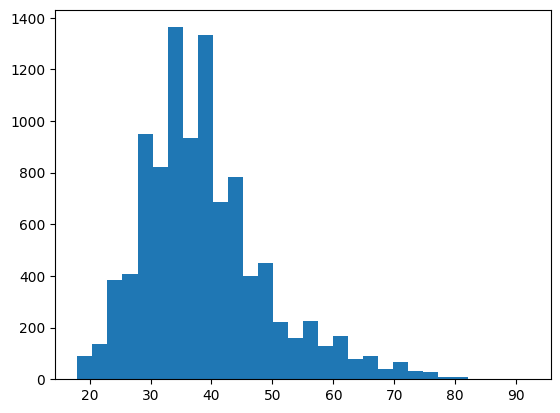

In [84]:
## Distribution of the age 
plt.hist(df['Age'],bins=30)
plt.show()

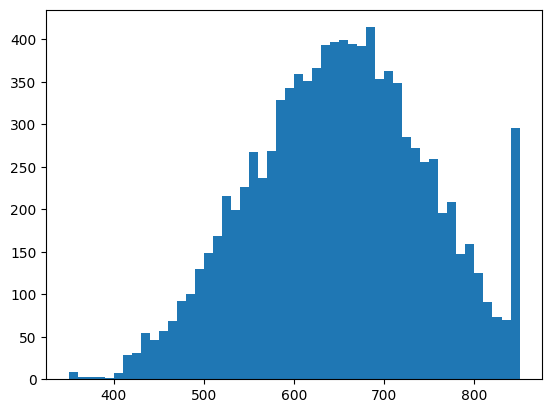

In [85]:
## Distribution of Creadit score
plt.hist(df['CreditScore'],bins=50)
plt.show()

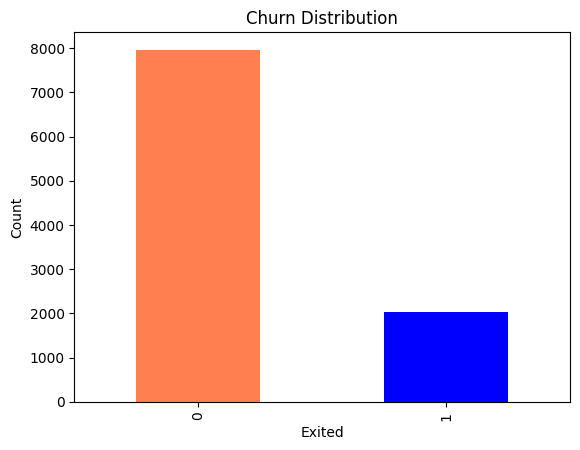

In [86]:
## Distibution of churn
df['Exited'].value_counts().plot(
    kind='bar',
    color=['coral', 'blue'],
    title='Churn Distribution'
)
plt.xlabel('Exited')
plt.ylabel('Count')
plt.show()

<Axes: title={'center': 'Churn Distribution by Gender'}, xlabel='Gender,Exited'>

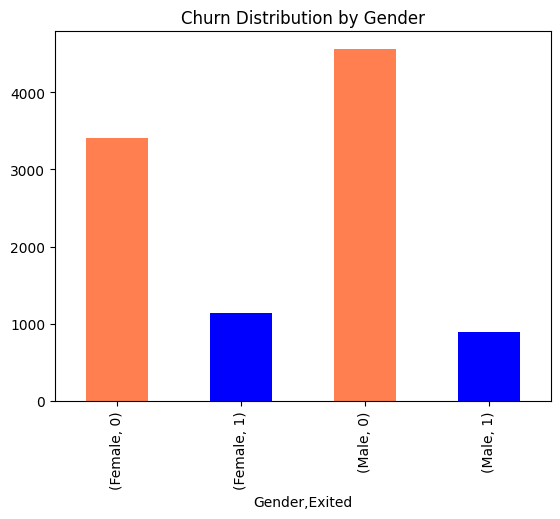

In [87]:
df.groupby('Gender')['Exited'].value_counts().plot(
       kind='bar',
    color=['coral', 'blue'],
    title='Churn Distribution by Gender'
)

Text(0.5, 1.0, 'Gender Vs Churn')

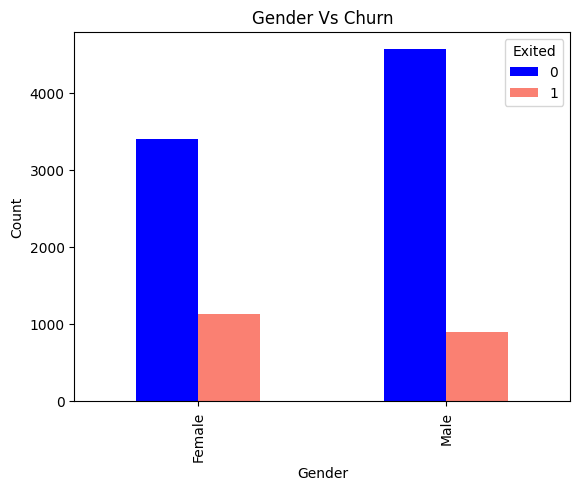

In [88]:
# Gender vs Churn
df.groupby('Gender')['Exited'].value_counts().unstack().plot(
    kind='bar', color=['blue', 'salmon'])
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title("Gender Vs Churn")

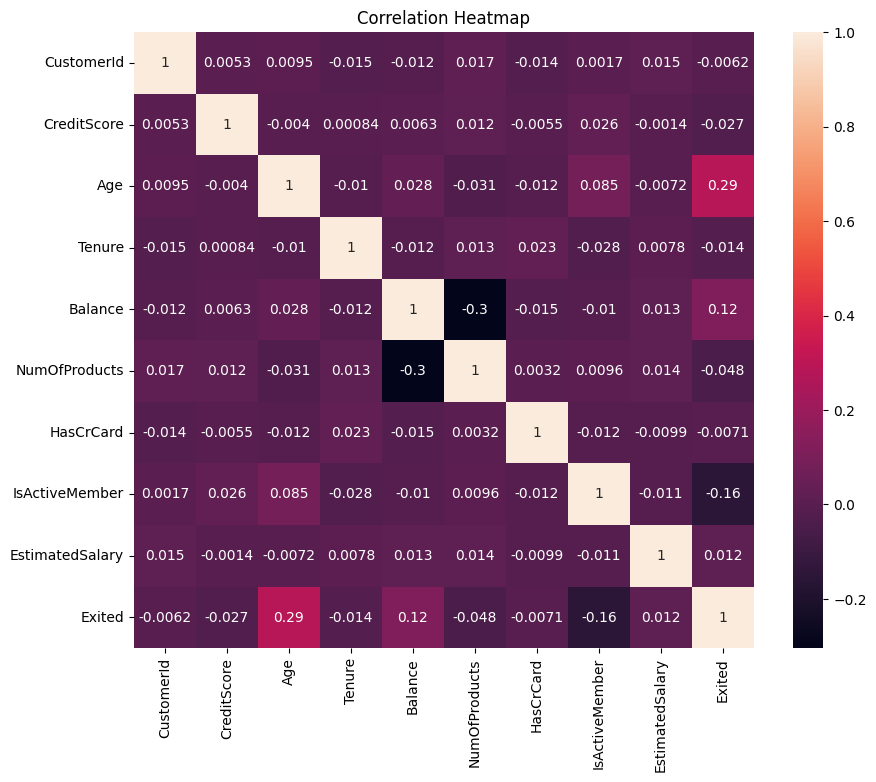

In [89]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap')
plt.show()

*Feature Engineering*

In [90]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

In [91]:
label=LabelEncoder()
df['Gender']=label.fit_transform(df['Gender'])

In [92]:
df['Gender'].unique()

array([0, 1])

In [93]:
df['Geography'].unique()

<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

In [94]:
df.dropna(subset=['Geography'],inplace=True)

In [95]:
## One Hot encoding 

## spare_out=Flase to get as an array not a matrix
ohe=OneHotEncoder(handle_unknown='ignore',sparse_output=False)
geo_encd=ohe.fit_transform(df[['Geography']])


In [96]:
geo_encd

array([[1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       ...,
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.]], shape=(10000, 3))

In [97]:

geo_df = pd.DataFrame(geo_encd, columns=ohe.get_feature_names_out(['Geography']))



In [98]:
geo_df.head()

,Geography_France,Geography_Germany,Geography_Spain
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0


In [99]:
geo_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Geography_France   10000 non-null  float64
 1   Geography_Germany  10000 non-null  float64
 2   Geography_Spain    10000 non-null  float64
dtypes: float64(3)
memory usage: 234.5 KB


In [101]:
print(geo_encd)

[[1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 ...
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]]


In [102]:
df=pd.concat((df,df_geo),axis=1)

In [103]:
df.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,15634602,619,France,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,15647311,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,15619304,502,France,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,15701354,699,France,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,15737888,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


In [107]:
df.drop(['Geography'],axis=1,inplace=True)

In [108]:
df.head()

,CustomerId,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,15634602,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,15647311,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,15619304,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,15701354,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,15737888,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


In [109]:
df['Gender'].value_counts()

Gender
1    5457
0    4543
Name: count, dtype: int64

In [112]:
df.to_csv('Churn_preprocssing.csv',index=False)